In [1]:
import os

print(os.listdir())

['.config', 'Sample - Superstore.csv', 'sample_data']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [3]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [5]:
df.dropna(inplace=True)

print("Missing values removed successfully")

Missing values removed successfully


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df['Order Date'].head())

0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]


In [7]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df[['Order Date', 'Year', 'Month']].head()

,Order Date,Year,Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [8]:
monthly_sales = df.groupby(
    ['Year', 'Month']
)['Sales'].sum().reset_index()

monthly_sales.head()

,Year,Month,Sales
0,2014,1,14236.895
1,2014,2,4519.892
2,2014,3,55691.009
3,2014,4,28295.345
4,2014,5,23648.287


In [11]:
X = monthly_sales[['Year', 'Month']]
y = monthly_sales['Sales']

In [12]:
model = LinearRegression()

model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [13]:
future_df = pd.DataFrame({
    'Year': [2024]*6,
    'Month': [1,2,3,4,5,6]
})

predictions = model.predict(future_df)

future_df['Predicted_Sales'] = predictions

future_df

,Year,Month,Predicted_Sales
0,2024,1,81780.568837
1,2024,2,87018.043008
2,2024,3,92255.517179
3,2024,4,97492.991350
4,2024,5,102730.465521
5,2024,6,107967.939692


In [14]:
train_predictions = model.predict(X)

mae = mean_absolute_error(y, train_predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 11883.441316206983


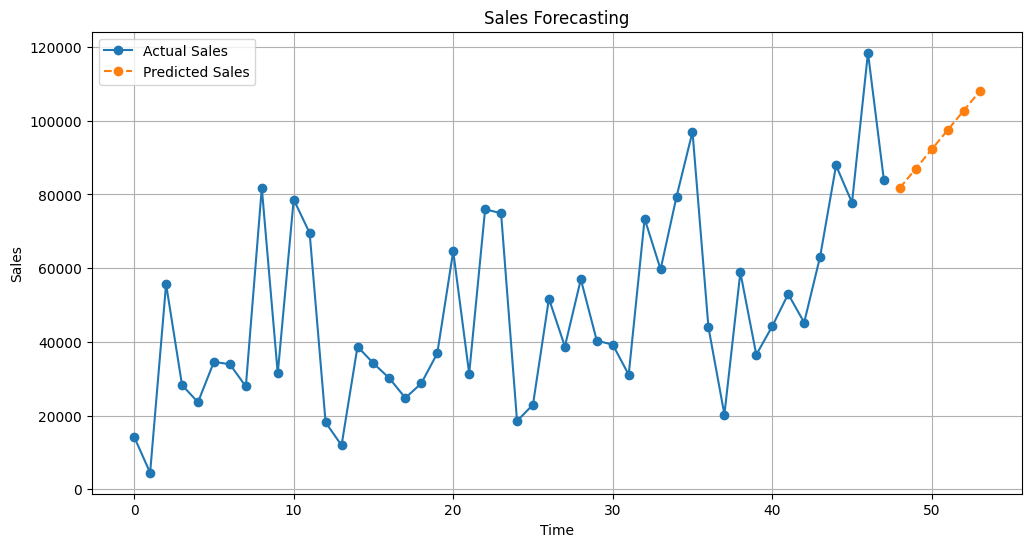

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    y,
    label='Actual Sales',
    marker='o'
)

plt.plot(
    future_df.index + len(monthly_sales),
    predictions,
    label='Predicted Sales',
    linestyle='--',
    marker='o'
)

plt.title('Sales Forecasting')

plt.xlabel('Time')

plt.ylabel('Sales')

plt.legend()

plt.grid(True)

plt.show()

# Business Insights

The model predicts future sales trends using historical business data.

The forecast shows expected sales patterns for upcoming months.

Businesses can use this information to:
- manage inventory
- improve staffing
- optimize budgets
- avoid stock shortages
- improve operational planning